# Quiz Praktikum — Logistic Regression

**Studi Kasus:** Prediksi tingkat stress mahasiswa berdasarkan pola tugas dan jam tidur menggunakan Logistic Regression.

| Label | Keterangan |
|-------|------------|
| 0 | Tidak Stress |
| 1 | Stress |

---

## 1. Import Library

In [83]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

import warnings
warnings.filterwarnings('ignore')

print('Library berhasil diimport!')

Library berhasil diimport!


---
## 2. Membaca Dataset

Dataset diambil dari hasil survei kelas yang mencakup atribut: NIM, Nama, Jumlah Tugas, Jumlah Tugas Melewati Deadline, Rata-rata Jam Tidur, dan Status Stress.

In [84]:
df = pd.read_csv('Survei Beban Tugas & Tingkat Stres Mahasiswa.csv')

# Rename kolom agar lebih mudah diakses
df.columns = ['Timestamp', 'Nama', 'NIM', 'Jumlah_Tugas', 'Tugas_Deadline', 'Jam_Tidur', 'Stress_Label', 'Stress']

print('Shape dataset:', df.shape)
print('\n5 Data Pertama:')
df.head()

Shape dataset: (42, 8)

5 Data Pertama:


,Timestamp,Nama,NIM,Jumlah_Tugas,Tugas_Deadline,Jam_Tidur,Stress_Label,Stress
0,5/7/2026 10:37:10,Muhammad Rayhan Mumtaz,2024081040,5,5,7,Stress,1
1,5/7/2026 16:08:00,Elpam Jovi Anata,2025081046,2,1,10,Tidak Stress,0
2,5/7/2026 16:08:15,RAFDY THAFJANI RUSDIANSYAH,2025081013,1,0,4,Tidak Stress,0
3,5/7/2026 16:08:37,Aura Keyfas Brilea,2025011015,4,2,6,Tidak Stress,0
4,5/7/2026 16:08:46,Nabila Dwi Novianti,2025011017,5,1,5,Stress,1


---
## 3. Data Cleaning

Proses data cleaning meliputi:
- Menghapus data kosong (*missing value*)
- Memastikan format angka konsisten
- Menghapus data duplikat berdasarkan NIM
- Memastikan kolom `Stress` sudah dalam format angka (0/1)

In [85]:
print('=== INFO SEBELUM CLEANING ===')
print(f'Jumlah baris  : {len(df)}')
print(f'Missing values:\n{df.isnull().sum()}')
print(f'Duplikat NIM  : {df.duplicated(subset=["NIM"]).sum()}')

=== INFO SEBELUM CLEANING ===
Jumlah baris  : 42
Missing values:
Timestamp         5
Nama              0
NIM               0
Jumlah_Tugas      0
Tugas_Deadline    0
Jam_Tidur         0
Stress_Label      0
Stress            0
dtype: int64
Duplikat NIM  : 1


In [86]:
# Hapus missing values
df.dropna(subset=['Jumlah_Tugas', 'Tugas_Deadline', 'Jam_Tidur', 'Stress'], inplace=True)

# Pastikan format angka konsisten
df['Jumlah_Tugas']  = pd.to_numeric(df['Jumlah_Tugas'], errors='coerce')
df['Tugas_Deadline'] = pd.to_numeric(df['Tugas_Deadline'], errors='coerce')
df['Jam_Tidur']      = pd.to_numeric(df['Jam_Tidur'], errors='coerce')
df['Stress']         = pd.to_numeric(df['Stress'], errors='coerce')

# Hapus baris yang gagal konversi
df.dropna(subset=['Jumlah_Tugas', 'Tugas_Deadline', 'Jam_Tidur', 'Stress'], inplace=True)

# Hapus duplikat berdasarkan NIM (pertahankan entri pertama)
df.drop_duplicates(subset=['NIM'], keep='first', inplace=True)

# Reset index
df.reset_index(drop=True, inplace=True)

print('=== INFO SETELAH CLEANING ===')
print(f'Jumlah baris  : {len(df)}')
print(f"Missing values: {df[['Jumlah_Tugas','Tugas_Deadline','Jam_Tidur','Stress']].isnull().sum().sum()}")
print(f'\nDistribusi Stress:\n{df["Stress"].value_counts().rename({0:"Tidak Stress",1:"Stress"})}')
df[['NIM','Nama','Jumlah_Tugas','Tugas_Deadline','Jam_Tidur','Stress']].head(10)

=== INFO SETELAH CLEANING ===
Jumlah baris  : 41
Missing values: 0

Distribusi Stress:
Stress
Stress          21
Tidak Stress    20
Name: count, dtype: int64


,NIM,Nama,Jumlah_Tugas,Tugas_Deadline,Jam_Tidur,Stress
0,2024081040,Muhammad Rayhan Mumtaz,5,5,7,1
1,2025081046,Elpam Jovi Anata,2,1,10,0
2,2025081013,RAFDY THAFJANI RUSDIANSYAH,1,0,4,0
3,2025011015,Aura Keyfas Brilea,4,2,6,0
4,2025011017,Nabila Dwi Novianti,5,1,5,1
5,2024081054,Icha Marisa Mahmuda,2,0,6,0
6,2024081024,Panji Kurnia Akbar,4,1,5,1
7,2024081055,Raden Najla Ramadhani,4,2,6,1
8,2024081020,Masagus Rakhalish Zhafran Pratama,3,1,5,0
9,2025081045,Rheina Dwi Amalia Gotama,7,0,7,0


---
## 4. Eksplorasi Data (EDA)

Visualisasi distribusi data untuk memahami pola sebelum membangun model.

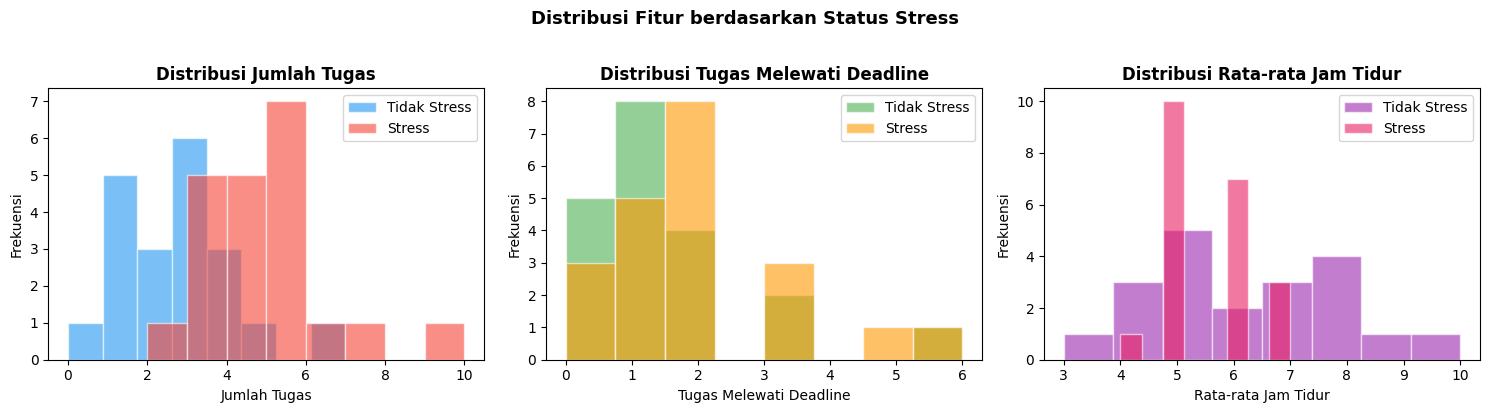

Plot EDA tersimpan.


In [87]:
import os

# Create output directory if it doesn't exist
os.makedirs('output', exist_ok=True)

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

features = ['Jumlah_Tugas', 'Tugas_Deadline', 'Jam_Tidur']
titles   = ['Jumlah Tugas', 'Tugas Melewati Deadline', 'Rata-rata Jam Tidur']
colors   = [['#2196F3','#F44336'], ['#4CAF50','#FF9800'], ['#9C27B0','#E91E63']]

for ax, feat, title, clr in zip(axes, features, titles, colors):
    for label, grp in df.groupby('Stress'):
        name = 'Tidak Stress' if label == 0 else 'Stress'
        ax.hist(grp[feat], alpha=0.6, label=name, color=clr[int(label)], bins=8, edgecolor='white')
    ax.set_title(f'Distribusi {title}', fontweight='bold')
    ax.set_xlabel(title)
    ax.set_ylabel('Frekuensi')
    ax.legend()

plt.suptitle('Distribusi Fitur berdasarkan Status Stress', fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('output/eda_distribusi.png', bbox_inches='tight', dpi=150)
plt.show()
print('Plot EDA tersimpan.')

---
## 5. Feature Selection

Fitur (X) yang digunakan:
- `Jumlah_Tugas` — total tugas yang dimiliki
- `Tugas_Deadline` — jumlah tugas yang melewati deadline
- `Jam_Tidur` — rata-rata jam tidur per hari

Target (y): `Stress` (0 = Tidak Stress, 1 = Stress)

In [88]:
X = df[['Jumlah_Tugas', 'Tugas_Deadline', 'Jam_Tidur']]
y = df['Stress']

print('Fitur (X):')
print(X.describe())
print(f'\nTarget (y) — distribusi kelas:')
print(y.value_counts().rename({0:'Tidak Stress (0)', 1:'Stress (1)'}))

Fitur (X):
       Jumlah_Tugas  Tugas_Deadline  Jam_Tidur
count     41.000000       41.000000  41.000000
mean       3.609756        1.682927   5.878049
std        1.921953        1.473754   1.469611
min        0.000000        0.000000   3.000000
25%        3.000000        1.000000   5.000000
50%        3.000000        1.000000   6.000000
75%        5.000000        2.000000   7.000000
max       10.000000        6.000000  10.000000

Target (y) — distribusi kelas:
Stress
Stress (1)          21
Tidak Stress (0)    20
Name: count, dtype: int64


---
## 6. Split Data — Training & Testing

Dataset dibagi dengan rasio **80% training** dan **20% testing** menggunakan `train_test_split` dengan `random_state=42` agar hasil reproducible.

In [89]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f'Total data   : {len(df)}')
print(f'Data training: {len(X_train)} ({len(X_train)/len(df)*100:.0f}%)')
print(f'Data testing : {len(X_test)} ({len(X_test)/len(df)*100:.0f}%)')
print(f'\nDistribusi y_train: {dict(y_train.value_counts())}')
print(f'Distribusi y_test : {dict(y_test.value_counts())}')

Total data   : 41
Data training: 32 (78%)
Data testing : 9 (22%)

Distribusi y_train: {0: np.int64(16), 1: np.int64(16)}
Distribusi y_test : {1: np.int64(5), 0: np.int64(4)}


---
## 7. Training Model — Logistic Regression

Model dilatih menggunakan `LogisticRegression()` dari scikit-learn. Logistic Regression bekerja dengan memodelkan probabilitas kelas menggunakan fungsi sigmoid:

$$P(y=1) = \frac{1}{1 + e^{-(\beta_0 + \beta_1 x_1 + \beta_2 x_2 + \beta_3 x_3)}}$$

In [90]:
model = LogisticRegression(random_state=42, max_iter=1000)
model.fit(X_train, y_train)

print('Model berhasil dilatih!')
print(f'\nKoefisien model:')
coef_df = pd.DataFrame({
    'Fitur'     : ['Jumlah_Tugas', 'Tugas_Deadline', 'Jam_Tidur'],
    'Koefisien' : model.coef_[0]
}).sort_values('Koefisien', ascending=False)
print(coef_df.to_string(index=False))
print(f'\nIntercept (bias): {model.intercept_[0]:.4f}')

Model berhasil dilatih!

Koefisien model:
         Fitur  Koefisien
  Jumlah_Tugas   0.637522
Tugas_Deadline   0.240674
     Jam_Tidur  -0.521516

Intercept (bias): 0.2729


---
## 8. Prediksi Data Testing

In [91]:
y_pred = model.predict(X_test)

hasil = X_test.copy()
hasil['Aktual']   = y_test.values
hasil['Prediksi'] = y_pred
hasil['Benar']    = (hasil['Aktual'] == hasil['Prediksi'])

print('Hasil Prediksi Data Testing:')
print(hasil.to_string())

Hasil Prediksi Data Testing:
    Jumlah_Tugas  Tugas_Deadline  Jam_Tidur  Aktual  Prediksi  Benar
32             5               2          4       0         1  False
14             0               0          8       0         0   True
21             5               2          6       1         1   True
29             3               0          7       1         0  False
35             5               1          6       1         1   True
0              5               5          7       1         1   True
12             1               1          5       0         0   True
4              5               1          5       1         1   True
22             3               1          7       0         0   True


---
## 9. Evaluasi Model

Evaluasi model dilakukan menggunakan tiga metrik utama:
- **Accuracy** — persentase prediksi yang benar
- **Confusion Matrix** — sebaran prediksi benar/salah per kelas
- **Classification Report** — precision, recall, F1-score

In [92]:
acc = accuracy_score(y_test, y_pred)
cm  = confusion_matrix(y_test, y_pred)
cr  = classification_report(y_test, y_pred, target_names=['Tidak Stress', 'Stress'])

print(f'Accuracy : {acc:.2%}')
print(f'\nClassification Report:\n{cr}')

Accuracy : 77.78%

Classification Report:
              precision    recall  f1-score   support

Tidak Stress       0.75      0.75      0.75         4
      Stress       0.80      0.80      0.80         5

    accuracy                           0.78         9
   macro avg       0.78      0.78      0.78         9
weighted avg       0.78      0.78      0.78         9



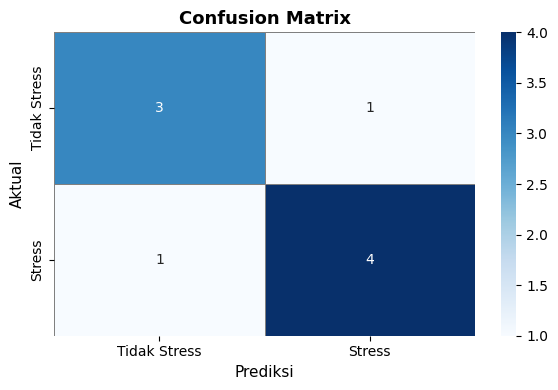

Confusion matrix tersimpan.


In [93]:
plt.figure(figsize=(6, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Tidak Stress', 'Stress'],
            yticklabels=['Tidak Stress', 'Stress'],
            linewidths=0.5, linecolor='gray')
plt.title('Confusion Matrix', fontweight='bold', fontsize=13)
plt.xlabel('Prediksi', fontsize=11)
plt.ylabel('Aktual', fontsize=11)
plt.tight_layout()
plt.savefig('output/confusion_matrix.png', dpi=150)
plt.show()
print('Confusion matrix tersimpan.')

---
## 10. Probabilitas Prediksi

Menggunakan `predict_proba()` untuk menampilkan probabilitas setiap prediksi. Kolom pertama adalah probabilitas **Tidak Stress (0)**, kolom kedua adalah probabilitas **Stress (1)**.

**Contoh interpretasi:** `[[0.22, 0.78]]` → 22% tidak stress, 78% stress.

In [94]:
y_proba = model.predict_proba(X_test)

proba_df = X_test.copy()
proba_df['Aktual']              = y_test.values
proba_df['Prediksi']            = y_pred
proba_df['Prob_Tidak_Stress']   = np.round(y_proba[:, 0], 4)
proba_df['Prob_Stress']         = np.round(y_proba[:, 1], 4)

print('Probabilitas Prediksi:')
print(proba_df.to_string())

Probabilitas Prediksi:
    Jumlah_Tugas  Tugas_Deadline  Jam_Tidur  Aktual  Prediksi  Prob_Tidak_Stress  Prob_Stress
32             5               2          4       0         1             0.1352       0.8648
14             0               0          8       0         0             0.9801       0.0199
21             5               2          6       1         1             0.3073       0.6927
29             3               0          7       1         0             0.8123       0.1877
35             5               1          6       1         1             0.3608       0.6392
0              5               5          7       1         1             0.2663       0.7337
12             1               1          5       0         0             0.8110       0.1890
4              5               1          5       1         1             0.2509       0.7491
22             3               1          7       0         0             0.7728       0.2272


---
## 11. Visualisasi Probabilitas Prediksi

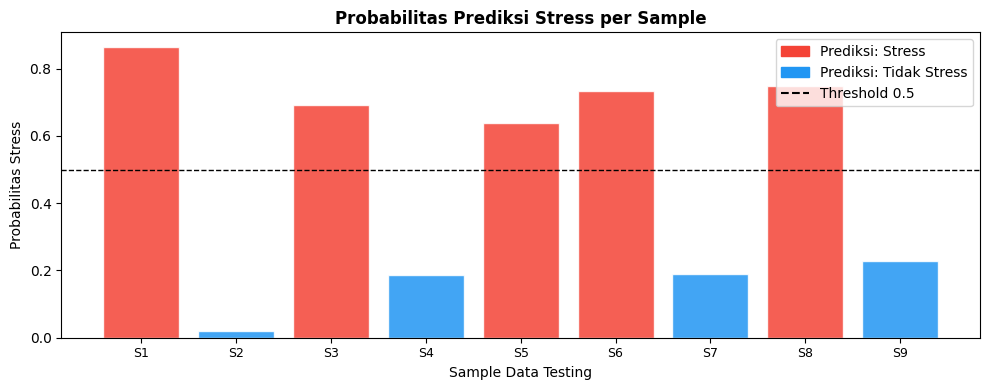

Plot probabilitas tersimpan.


In [95]:
fig, ax = plt.subplots(figsize=(10, 4))

x_pos = range(len(proba_df))
ax.bar(x_pos, proba_df['Prob_Stress'], color=[
    '#F44336' if p >= 0.5 else '#2196F3' for p in proba_df['Prob_Stress']
], edgecolor='white', alpha=0.85)
ax.axhline(0.5, color='black', linestyle='--', linewidth=1, label='Threshold = 0.5')

ax.set_xticks(x_pos)
ax.set_xticklabels([f'S{i+1}' for i in x_pos], fontsize=9)
ax.set_xlabel('Sample Data Testing')
ax.set_ylabel('Probabilitas Stress')
ax.set_title('Probabilitas Prediksi Stress per Sample', fontweight='bold')
ax.legend()

from matplotlib.patches import Patch
ax.legend(handles=[
    Patch(color='#F44336', label='Prediksi: Stress'),
    Patch(color='#2196F3', label='Prediksi: Tidak Stress'),
    plt.Line2D([0],[0], color='black', linestyle='--', label='Threshold 0.5')
])

plt.tight_layout()
plt.savefig('output/probabilitas_prediksi.png', dpi=150)
plt.show()
print('Plot probabilitas tersimpan.')

---
## 12. Analisis

### 1. Mengapa Logistic Regression cocok untuk kasus ini?
Logistic Regression cocok karena target variabel bersifat **biner** (0 = Tidak Stress, 1 = Stress). Model ini menghasilkan **probabilitas** antara 0–1 menggunakan fungsi sigmoid, sehingga dapat memberikan prediksi kelas sekaligus tingkat keyakinan prediksi. Selain itu, model ini **sederhana, cepat dilatih**, dan mudah diinterpretasi melalui nilai koefisiennya.

### 2. Mengapa probabilitas penting dalam prediksi stress?
Probabilitas penting karena stress bukan kondisi hitam-putih. Seseorang dengan probabilitas stress **70%** memiliki risiko berbeda dibanding yang **95%**. Dengan informasi probabilitas, dosen atau konselor dapat **memprioritaskan intervensi** pada mahasiswa berisiko tinggi sebelum kondisi memburuk.

### 3. Faktor yang paling memengaruhi stress mahasiswa?
Berdasarkan koefisien model:
- **Jumlah tugas melewati deadline** — koefisien positif tertinggi → paling berkontribusi pada stress
- **Jumlah tugas** — koefisien positif → semakin banyak tugas, semakin besar risiko stress
- **Rata-rata jam tidur** — koefisien negatif → semakin banyak tidur, semakin kecil risiko stress

### 4. Kelemahan model yang dibuat?
- **Ukuran dataset kecil** (~40 data) → model rentan *overfitting* atau tidak representatif
- **Fitur terbatas** — faktor psikologis lain (tekanan sosial, keuangan, kesehatan) tidak dimasukkan
- **Asumsi linearitas** — Logistic Regression mengasumsikan hubungan linear antara fitur dan log-odds, yang mungkin tidak selalu tepat
- **Bias survei** — data berasal dari satu kelas saja sehingga tidak bisa digeneralisasi

---
## 13. Simpan Dataset Hasil Cleaning

In [96]:
df[['NIM','Nama','Jumlah_Tugas','Tugas_Deadline','Jam_Tidur','Stress']].to_csv(
    'output/dataset_cleaned.csv', index=False
)
print('Dataset hasil cleaning tersimpan di output/dataset_cleaned.csv')
print(f'Total data bersih: {len(df)} baris')

Dataset hasil cleaning tersimpan di output/dataset_cleaned.csv
Total data bersih: 41 baris
